In [1]:
print("""This script was written in support of the experiments carried out in:
Nic Ezzell, Lev Barash, Itay Hen, A universal black-box quantum Monte Carlo approach to quantum phase transitions, arXiv:2408.03924v2 (2025).""")

This script was written in support of the experiments carried out in:
Nic Ezzell, Lev Barash, Itay Hen, A universal black-box quantum Monte Carlo approach to quantum phase transitions, arXiv:2408.03924v2 (2025).


In [2]:
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import glob
import pandas as pd
import sys
import re
import scipy
sys.path.append("../../utils")
from exact_calculations import (prl_gs_chiE, prl_gs_chiF, prl_beta_chiE,
prl_beta_chiX, prl_beta_chiF, prl_gs_fidsus)

matplotlib.style.use("./style.mplstyle")
new_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r"\usepackage{amsmath}\usepackage{amsfonts}")

In [3]:
fname = "../data/sparse_meas_tfim_beta_sweep_summary.csv"
cols = [
    "filename",
    "kind",
    "beta",
    "Tsteps",
    "steps",
    "stepsPerMeasurement",
    "Nbins",
    "nprocs"
]
for j in range(6):
    cols += [f"rank{j}_time_s"]
cols += ["total_mean_q",
    "total_max_q",
    "total_mean_sgnW",
    "total_std_sgnW",
    "wall_clock_seconds",
    "total_elapsed_cpu_seconds"
]
df = pd.read_csv(fname, names=cols, skiprows=1)

df.head()

,filename,kind,beta,Tsteps,steps,stepsPerMeasurement,Nbins,nprocs,rank0_time_s,rank1_time_s,rank2_time_s,rank3_time_s,rank4_time_s,rank5_time_s,total_mean_q,total_max_q,total_mean_sgnW,total_std_sgnW,wall_clock_seconds,total_elapsed_cpu_seconds
0,notstep_nomeas_tfim_fidsus_beta_0.1.txt,nomeas,0.100000,0,1000000,1,100,6,0.420978,0.348785,0.374549,0.351083,0.442416,0.376800,0.158067,6.0,1.0,0.0,0.442817,2.314611
1,notstep_nomeas_tfim_fidsus_beta_0.16551724.txt,nomeas,0.165517,0,1000000,1,100,6,0.509477,0.510559,0.511163,0.508144,0.508208,0.505643,0.425767,8.0,1.0,0.0,0.511566,3.053194
2,notstep_nomeas_tfim_fidsus_beta_0.23103448.txt,nomeas,0.231034,0,1000000,1,100,6,0.602071,0.602689,0.604821,0.603920,0.604399,0.606361,0.786967,8.0,1.0,0.0,0.606643,3.624261
3,notstep_nomeas_tfim_fidsus_beta_0.29655172.txt,nomeas,0.296552,0,1000000,1,100,6,0.706624,0.716332,0.712013,0.709779,0.706244,0.708481,1.247300,12.0,1.0,0.0,0.716634,4.259473
4,notstep_nomeas_tfim_fidsus_beta_0.36206897.txt,nomeas,0.362069,0,1000000,1,100,6,1.017970,1.178420,0.858863,0.861795,0.852493,0.849167,1.760600,14.0,1.0,0.0,1.178668,5.618709


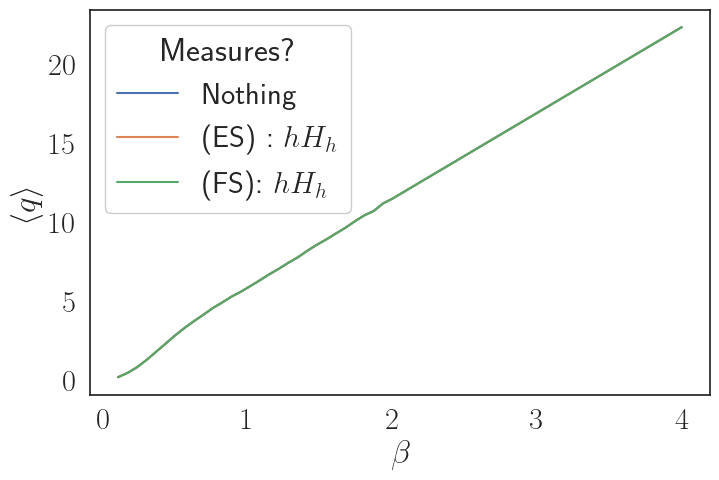

In [10]:
sns.set_theme(style="white", font_scale=2)
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.lineplot(data=df, x='beta', hue="kind", y='total_mean_q', errorbar="pi", markersize=6)
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$\langle q \rangle$")
hue_order = ["nomeas", "esus", "fidsus"]
label_map = {"nomeas": "Nothing", "esus": r"(ES) : $h H_h$", "fidsus": r"(FS): $h H_h$"}
# --- build legend from *line* handles only (ignore CI PolyCollections) ---
handles, labels = ax.get_legend_handles_labels()

line_handles = []
for kind in hue_order:
    # find the first handle whose label == kind and is a Line2D
    for h, l in zip(handles, labels):
        if l == kind and isinstance(h, matplotlib.lines.Line2D):
            line_handles.append(h)
            break

ax.legend(
    handles=line_handles,
    labels=[label_map[k] for k in hue_order],
    title="Measures?",
    frameon=True,
    loc="upper left",
)
fig = ax.get_figure()
fig.savefig("blackbox_paper_figures/fig_supplemental_just_qavg_of_new_prb_fig3_experiment_plots.pdf", dpi=800, bbox_inches="tight")

In [5]:
# --- assume df is your wide DataFrame ---

# 1) Find all rank columns automatically
rank_cols = [c for c in df.columns if re.fullmatch(r"rank\d+_time_s", c)]

# 2) Melt the rank columns into a long format
df_long = df.melt(
    id_vars=["kind", "beta"], 
    value_vars=rank_cols,
    var_name="rank", 
    value_name="time_s"
)

# 3) Optionally extract the numeric rank index (not needed for plotting)
df_long["rank_index"] = df_long["rank"].str.extract(r"(\d+)").astype(int)

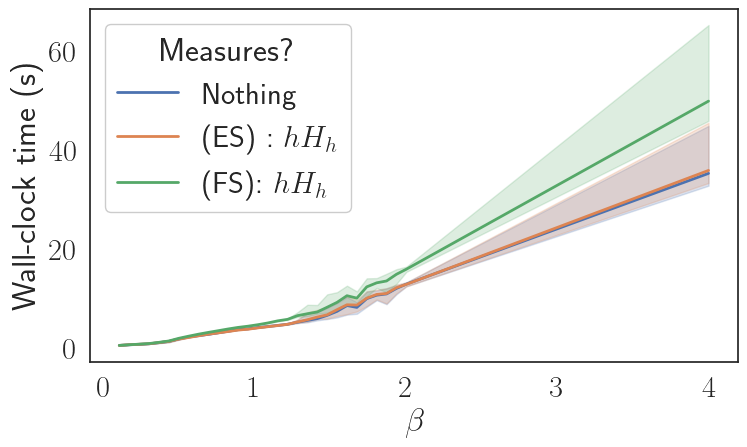

In [11]:
# 4) Plot: seaborn automatically uses the variation across ranks to estimate CI
sns.set_theme(style="white", font_scale=2)
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.lineplot(
    data=df_long,
    x="beta", y="time_s", hue="kind", linewidth=2,
    errorbar="pi",  # default 95% confidence interval
)

ax.set_xlabel(r"$\beta$")
ax.set_ylabel("Wall-clock time (s)")
hue_order = ["nomeas", "esus", "fidsus"]
#label_map = {"nomeas": "Nothing", "esus": r"$\chi^\beta_E$ (ES) : $H_h$", "fidsus": r"$\chi^\beta_F$ (FS): $H_h$"}
label_map = {"nomeas": "Nothing", "esus": r"(ES) : $h H_h$", "fidsus": r"(FS): $h H_h$"}
# --- build legend from *line* handles only (ignore CI PolyCollections) ---
handles, labels = ax.get_legend_handles_labels()

line_handles = []
for kind in hue_order:
    # find the first handle whose label == kind and is a Line2D
    for h, l in zip(handles, labels):
        if l == kind and isinstance(h, matplotlib.lines.Line2D):
            line_handles.append(h)
            break

ax.legend(
    handles=line_handles,
    labels=[label_map[k] for k in hue_order],
    title="Measures?",
    frameon=True,
    loc="upper left",
)
plt.tight_layout()
plt.savefig("blackbox_paper_figures/fig_supplemental_sparse_simtime_of_new_prb_fig3_experiment_plots.pdf", dpi=800, bbox_inches="tight")

/var/folders/2w/_70fq7w11c36fkhz8pnqp8gw0000gp/T/ipykernel_32225/2106121946.py:8: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.lineplot(
/var/folders/2w/_70fq7w11c36fkhz8pnqp8gw0000gp/T/ipykernel_32225/2106121946.py:54: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.lineplot(


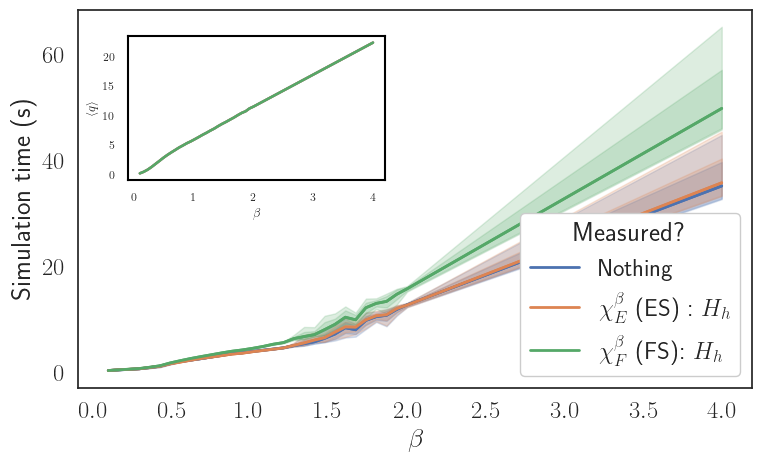

In [12]:
# optional: consistent palette across both plots
palette = sns.color_palette("deep")

sns.set_theme(style="white", font_scale=1.6)
fig, ax = plt.subplots(figsize=(8, 5))

# --- Main plot: time vs beta with CIs across ranks (shared legend) ---
sns.lineplot(
    data=df_long,
    x="beta", y="time_s", hue="kind",
    linewidth=2, errorbar="pi", palette=palette, ax=ax,
)

ax.set_xlabel(r"$\beta$")
ax.set_ylabel("Simulation time (s)")

# Keep legend on the main plot (shared legend)
#leg = ax.legend(title="Measured?", labels=["nothing", "ES", "FS"], frameon=True, loc="lower right")
# Ensure a predictable order that matches your kinds
hue_order = ["nomeas", "esus", "fidsus"]
label_map = {"nomeas": "Nothing", "esus": r"$\chi^\beta_E$ (ES) : $H_h$", "fidsus": r"$\chi^\beta_F$ (FS): $H_h$"}

# Main plot
ax = sns.lineplot(
    data=df_long,
    x="beta", y="time_s",
    hue="kind", hue_order=hue_order,
    linewidth=2, errorbar="ci",  # keeps shaded CI
)

# --- build legend from *line* handles only (ignore CI PolyCollections) ---
handles, labels = ax.get_legend_handles_labels()

line_handles = []
for kind in hue_order:
    # find the first handle whose label == kind and is a Line2D
    for h, l in zip(handles, labels):
        if l == kind and isinstance(h, matplotlib.lines.Line2D):
            line_handles.append(h)
            break

ax.legend(
    handles=line_handles,
    labels=[label_map[k] for k in hue_order],
    title="Measured?",
    frameon=True,
    loc="lower right",
)

# --- Inset: ⟨q⟩ vs beta (no grid), shifted right, boxed clearly ---
# [x0, y0, width, height] in axes coordinates; adjust to taste
inset_ax = ax.inset_axes([0.075, 0.55, 0.38, 0.38])  # right/bottom area, avoids label clashes

sns.lineplot(
    data=df, x="beta", y="total_mean_q", hue="kind", errorbar="pi",
    palette=palette, ax=inset_ax, legend=False, linewidth=1.8
)

# No grid in inset
inset_ax.grid(False)

# Labels and ticks smaller
inset_ax.set_xlabel(r"$\beta$", fontsize=9)
inset_ax.set_ylabel(r"$\langle q \rangle$", fontsize=9)
inset_ax.tick_params(labelsize=8)

# Make the inset clearly delineated: solid white background + thick spines
inset_ax.set_facecolor("white")
for spine in inset_ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor("black")

# If main legend overlaps inset, move the legend slightly
# leg.set_bbox_to_anchor((1.02, 1), transform=ax.transAxes)  # optional: put legend outside

plt.tight_layout()
plt.show()

In [39]:
# 1) Compute the median time for each (kind, beta)
median_df = (
    df_long
    .groupby(["kind", "beta"], as_index=False)["time_s"]
    .median()
    .rename(columns={"time_s": "median_time_s"})
)

# 2) Fit power law t = c * beta^k for each kind
fit_results = []

for kind, group in median_df.groupby("kind"):
    x = group["beta"].to_numpy()
    y = group["median_time_s"].to_numpy()

    # filter out nonpositive values
    mask = (x > 0) & (y > 0)
    x, y = x[mask], y[mask]

    # log–log linear regression
    k, log_c = np.polyfit(np.log(x), np.log(y), 1)
    c = np.exp(log_c)
    fit_results.append({"kind": kind, "c": c, "k": k})

fit_df = pd.DataFrame(fit_results)
print(fit_df)


     kind          c         k
0    esus  59.537844  1.226862
1  fidsus  60.419420  1.234812
2  nomeas  58.942997  1.225046


/var/folders/2w/_70fq7w11c36fkhz8pnqp8gw0000gp/T/ipykernel_91472/3314929915.py:7: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(


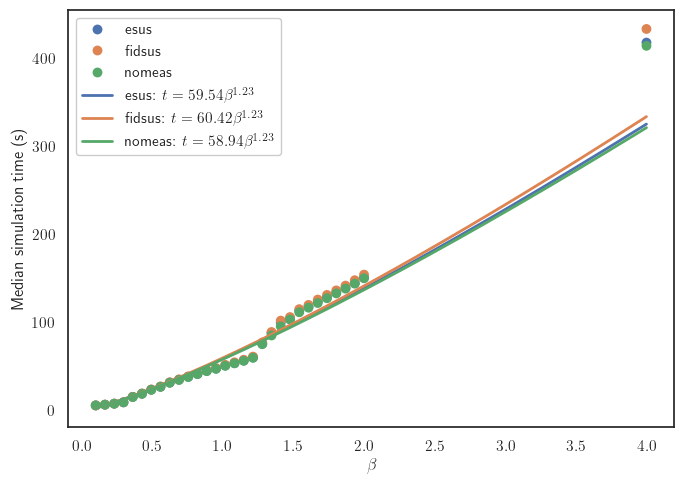

In [40]:
sns.set_theme(style="white")  # no grid
palette = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(7, 5))

# 1) Plot the median points
sns.scatterplot(
    data=median_df,
    x="beta", y="median_time_s", hue="kind",
    palette=palette, ax=ax, s=50, edgecolor="none", legend=True
)

# 2) Overlay fitted curves
beta_fit = np.linspace(median_df["beta"].min(), median_df["beta"].max(), 300)
for _, row in fit_df.iterrows():
    kind, c, k = row["kind"], row["c"], row["k"]
    plt.plot(
        beta_fit, c * beta_fit**k,
        label=fr"{kind}: $t = {c:.2f}\beta^{{{k:.2f}}}$",
        linewidth=2
    )

ax.set_xlabel(r"$\beta$")
ax.set_ylabel("Median simulation time (s)")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()
